In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Параметры подключения
server = 'hq-srv-eis-new.irgups.ru'
database = 'eis_irgups'
username = 'eis_irgups'
password = 'eis_irgups'

# Строка подключения
connection_string = f"mysql+pymysql://{username}:{password}@{server}/{database}"
engine = create_engine(connection_string)

# SQL-запрос (убран лишний отступ)
query = """
SELECT 
    ps.id AS presentation_id,
    pt.name AS presentation_type,
    ss.id AS sign_status_id,
    ss.value AS sig_status_name,
    CONCAT_WS(' ', p.name1, p.name2, p.name3) AS fio,
    DATE_FORMAT(ps.date_create, '%%d.%%m.%%Y') AS date_create,
    c.contract_id,
    sc.id AS stud_id,
    f.short_name AS fac_short_name,
    e.name1,
    e.name2,
    e.name3,
    pa.queue,
    pa.approve_date,
    o.start_date
FROM presentation_stud ps
JOIN presentation_type pt ON pt.id = ps.presentation_type_id
JOIN sign_status ss ON ss.id = ps.status_id
JOIN stud_cards sc ON sc.id = ps.stud_id
JOIN persons p ON p.id = sc.person_id
JOIN courses c ON c.stud_id = sc.id AND c.active = 1
JOIN stud_groups sg ON sg.id = c.group_id
JOIN faculties f ON f.id = sg.fac_id
JOIN presentation_approval pa ON pa.presentation_id = ps.id
JOIN employes e ON e.id = pa.emp_id
JOIN stud_order so ON so.presentation_stud_id = ps.id
JOIN orders o ON o.id = so.order_id
WHERE ps.active = 1;
"""

try:
    # Выполняем запрос и загружаем данные в DataFrame
    df = pd.read_sql(query, engine)
    print("✅ Данные успешно загружены!")
    print(df.head())  # Выводим первые строки данных

except ImportError as ie:
    print(f"Ошибка импорта: {ie}. Убедитесь, что установлены все необходимые библиотеки.")
except Exception as e:
    print(f"Ошибка при выполнении запроса: {e}")

✅ Данные успешно загружены!
   presentation_id            presentation_type  sign_status_id  \
0               13  Представление об отчислении               3   
1               13  Представление об отчислении               3   
2               13  Представление об отчислении               3   
3               13  Представление об отчислении               3   
4               15  Представление об отчислении               3   

  sig_status_name                       fio date_create  contract_id  stud_id  \
0      Согласован   Трашков Роман Андреевич  12.05.2025            0   125416   
1      Согласован   Трашков Роман Андреевич  12.05.2025            0   125416   
2      Согласован   Трашков Роман Андреевич  12.05.2025            0   125416   
3      Согласован   Трашков Роман Андреевич  12.05.2025            0   125416   
4      Согласован  Графов Вячеслав Игоревич  13.05.2025            1   116994   

  fac_short_name         name1     name2           name3  queue  \
0           ФЭи

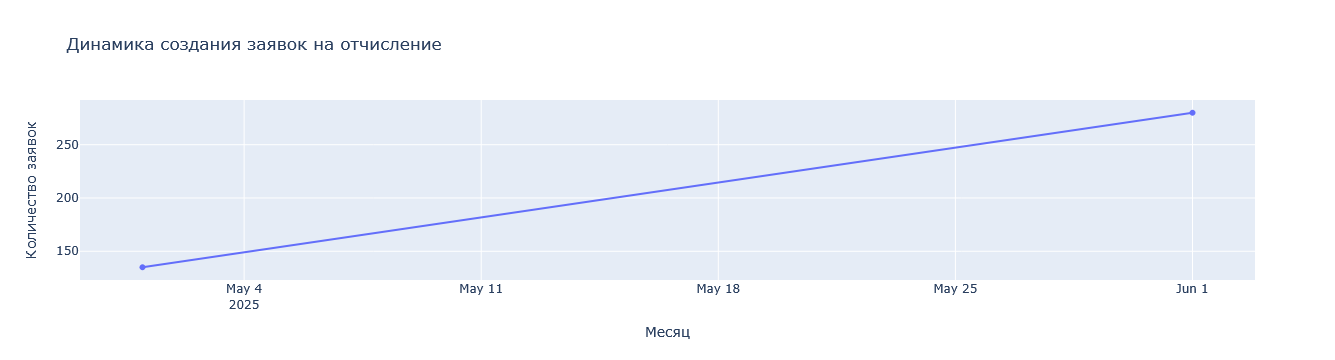

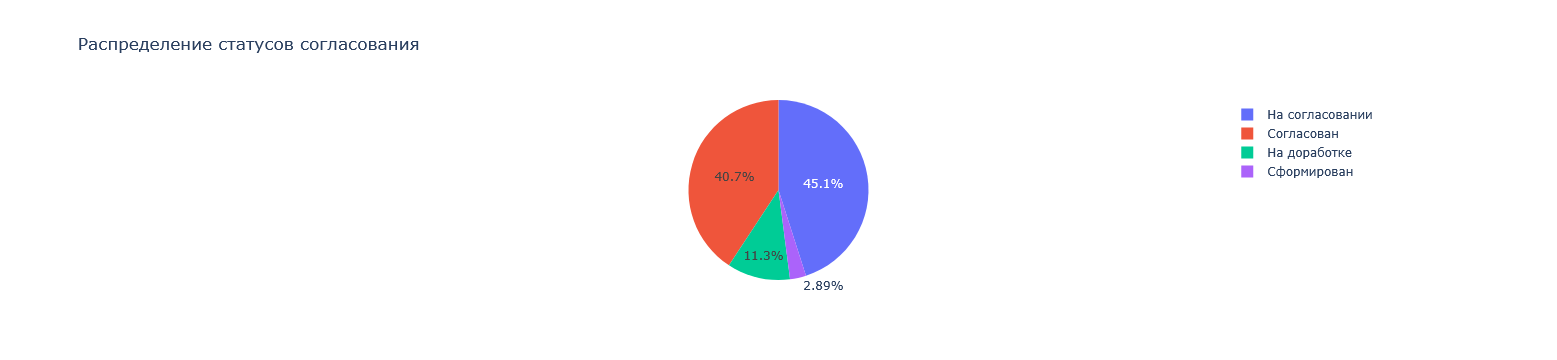

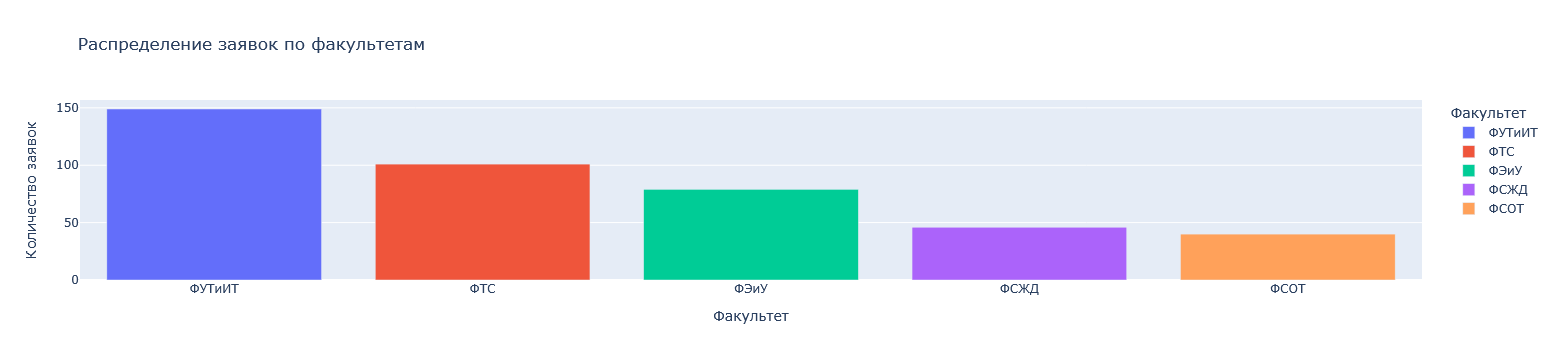

In [2]:
import pandas as pd
import plotly.express as px

# Пример: Динамика создания заявок
df['date_create'] = pd.to_datetime(df['date_create'], format='%d.%m.%Y')  # Преобразуем дату в datetime
df['year_month'] = df['date_create'].dt.to_period('M').astype(str)  # Группируем по месяцам

requests_by_month = df.groupby('year_month').size().reset_index(name='count')

fig_requests = px.line(
    requests_by_month,
    x='year_month',
    y='count',
    title='Динамика создания заявок на отчисление',
    markers=True
)
fig_requests.update_layout(xaxis_title='Месяц', yaxis_title='Количество заявок')
fig_requests.show()

# Пример: Распределение статусов согласования
status_distribution = df['sig_status_name'].value_counts().reset_index()
status_distribution.columns = ['Статус', 'Количество']

fig_status = px.pie(
    status_distribution,
    names='Статус',
    values='Количество',
    title='Распределение статусов согласования'
)
fig_status.show()

# Пример: Распределение заявок по факультетам
faculty_distribution = df['fac_short_name'].value_counts().reset_index()
faculty_distribution.columns = ['Факультет', 'Количество']

fig_faculty = px.bar(
    faculty_distribution,
    x='Факультет',
    y='Количество',
    title='Распределение заявок по факультетам',
    color='Факультет'
)
fig_faculty.update_layout(xaxis_title='Факультет', yaxis_title='Количество заявок')
fig_faculty.show()

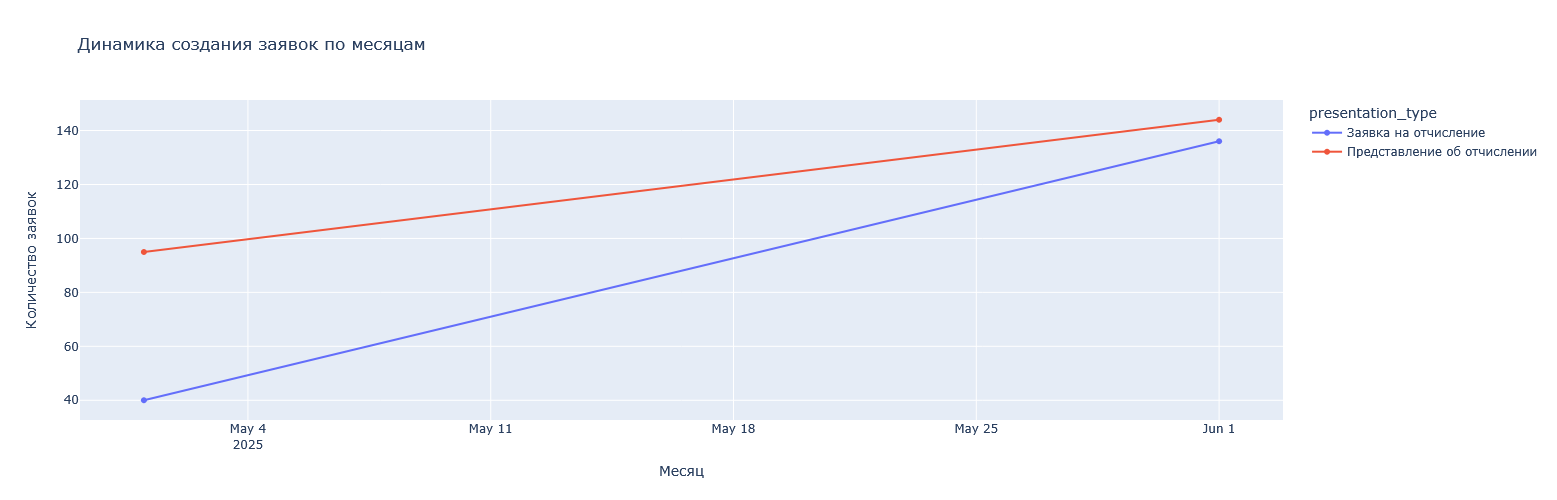

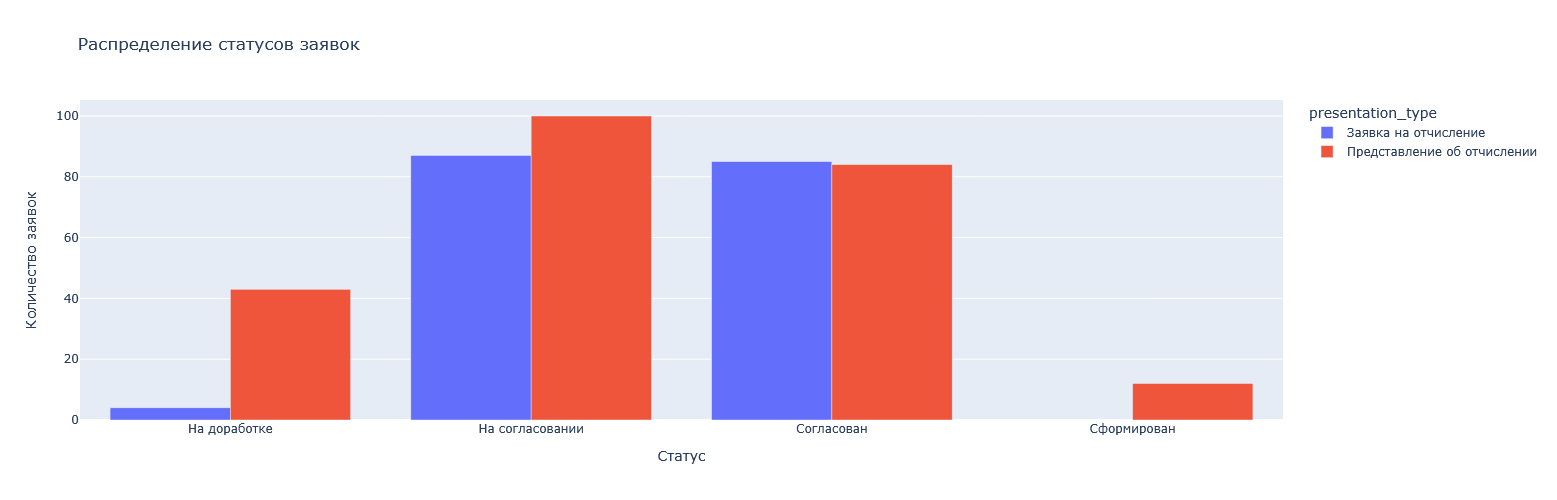

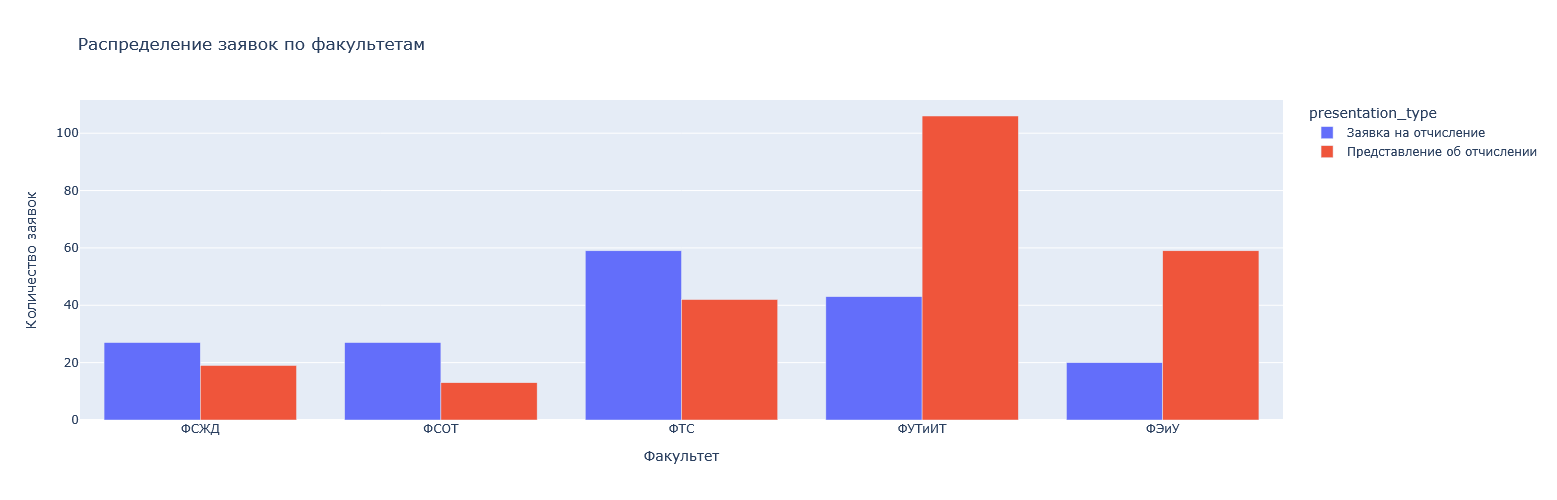

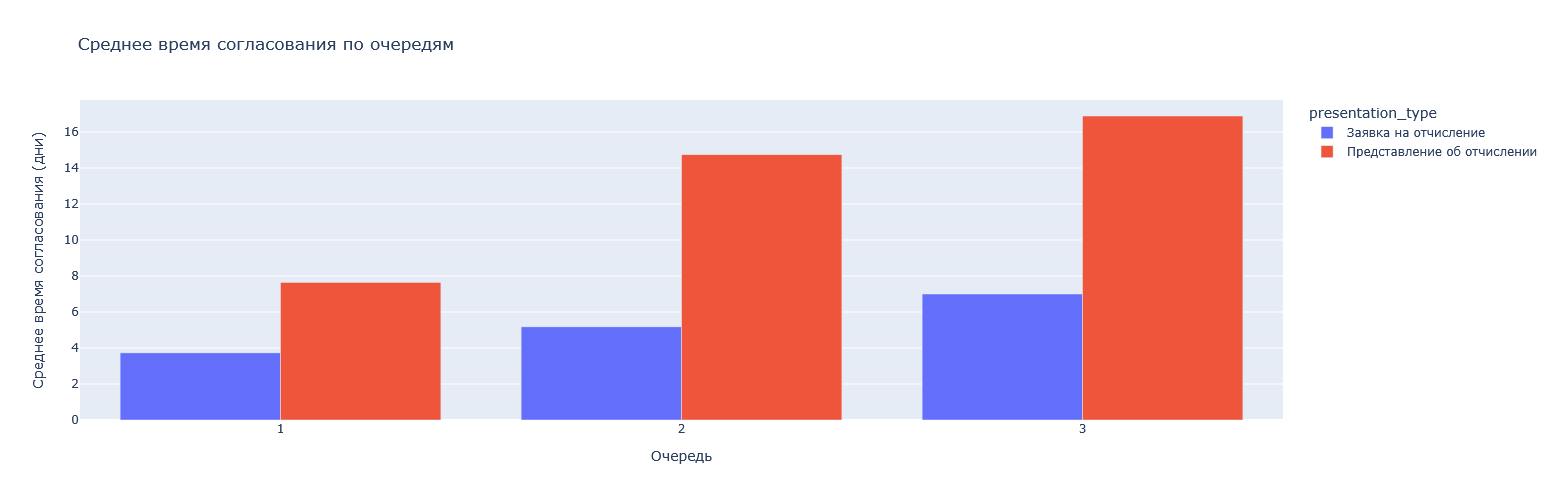

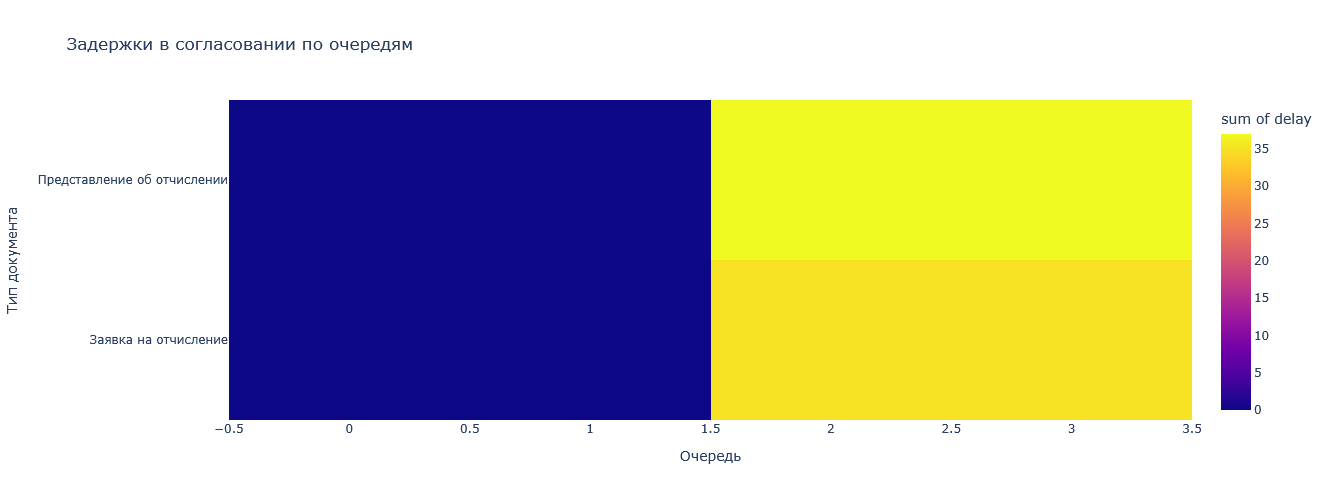

In [3]:
import pandas as pd
import plotly.express as px

# Загрузка данных (предполагается, что данные уже загружены в DataFrame df)
# df = pd.read_sql(query, engine)

# 1. Динамика создания заявок
df['date_create'] = pd.to_datetime(df['date_create'], format='%d.%m.%Y')  # Преобразуем дату в формат datetime
df['month'] = df['date_create'].dt.to_period('M').astype(str)  # Группируем по месяцам

# Группируем данные по типу документа и месяцам
dynamic_data = df.groupby(['presentation_type', 'month']).size().reset_index(name='count')

fig_dynamic = px.line(
    dynamic_data,
    x='month',
    y='count',
    color='presentation_type',
    title='Динамика создания заявок по месяцам',
    markers=True,
    height=500,
    width=1000
)
fig_dynamic.update_layout(xaxis_title='Месяц', yaxis_title='Количество заявок')
fig_dynamic.show()

# 2. Распределение статусов
status_data = df.groupby(['presentation_type', 'sig_status_name']).size().reset_index(name='count')

fig_status = px.bar(
    status_data,
    x='sig_status_name',
    y='count',
    color='presentation_type',
    title='Распределение статусов заявок',
    barmode='group',
    height=500,
    width=1000
)
fig_status.update_layout(xaxis_title='Статус', yaxis_title='Количество заявок')
fig_status.show()

# 3. Анализ по факультетам
faculty_data = df.groupby(['fac_short_name', 'presentation_type']).size().reset_index(name='count')

fig_faculty = px.bar(
    faculty_data,
    x='fac_short_name',
    y='count',
    color='presentation_type',
    title='Распределение заявок по факультетам',
    barmode='group',
    height=500,
    width=1000
)
fig_faculty.update_layout(xaxis_title='Факультет', yaxis_title='Количество заявок')
fig_faculty.show()

# 4. Очереди согласования
# Фильтруем данные, где approve_date заполнено
df['approve_date'] = pd.to_datetime(df['approve_date'])
df['start_date'] = pd.to_datetime(df['start_date'])

# Рассчитываем время согласования
df['approval_time'] = (df['approve_date'] - df['date_create']).dt.days

queue_data = df.groupby(['queue', 'presentation_type'])['approval_time'].mean().reset_index()

fig_queue = px.bar(
    queue_data,
    x='queue',
    y='approval_time',
    color='presentation_type',
    title='Среднее время согласования по очередям',
    barmode='group',
    height=500,
    width=1000
)
fig_queue.update_layout(xaxis_title='Очередь', yaxis_title='Среднее время согласования (дни)')
fig_queue.show()

# 5. Тепловая карта задержек
# Считаем количество задержек для каждой очереди
df['delay'] = df.apply(lambda row: 1 if (row['queue'] == 2 and row['approval_time'] > 1) or 
                                     (row['queue'] == 3 and row['approval_time'] > 2) else 0, axis=1)

delay_data = df.groupby(['queue', 'presentation_type'])['delay'].sum().reset_index()

fig_heatmap = px.density_heatmap(
    delay_data,
    x='queue',
    y='presentation_type',
    z='delay',
    title='Задержки в согласовании по очередям',
    height=500,
    width=1000
)
fig_heatmap.update_layout(xaxis_title='Очередь', yaxis_title='Тип документа')
fig_heatmap.show()

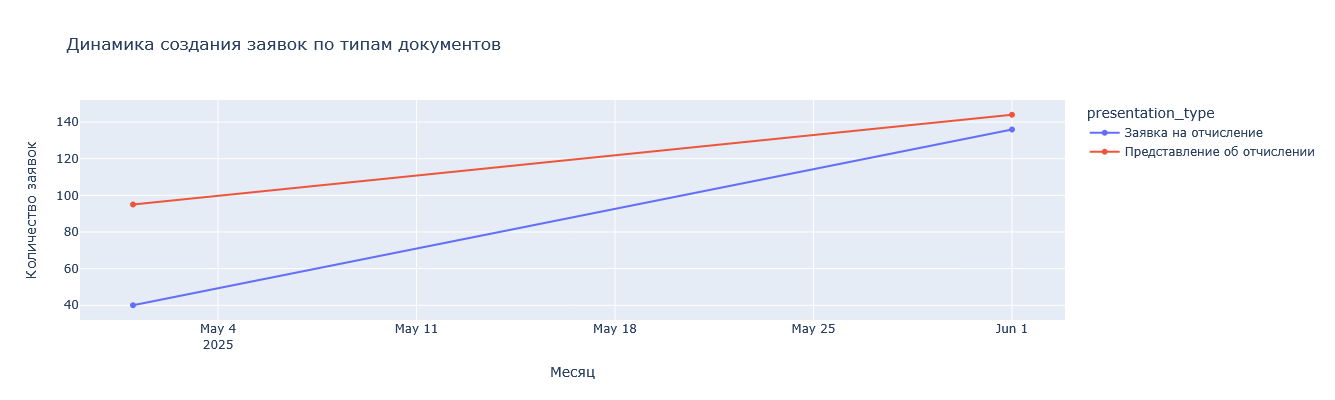

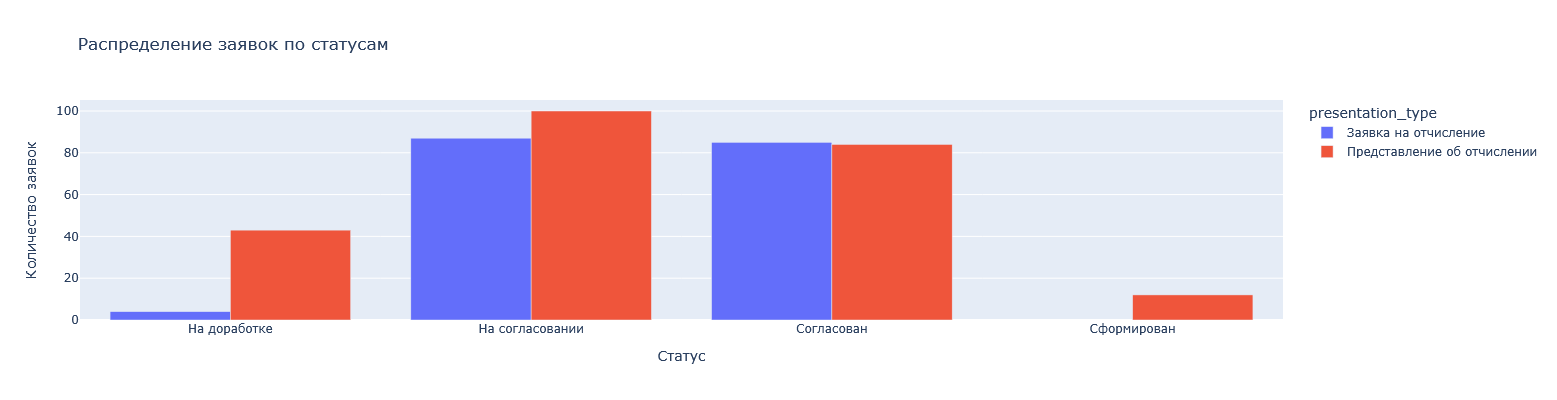

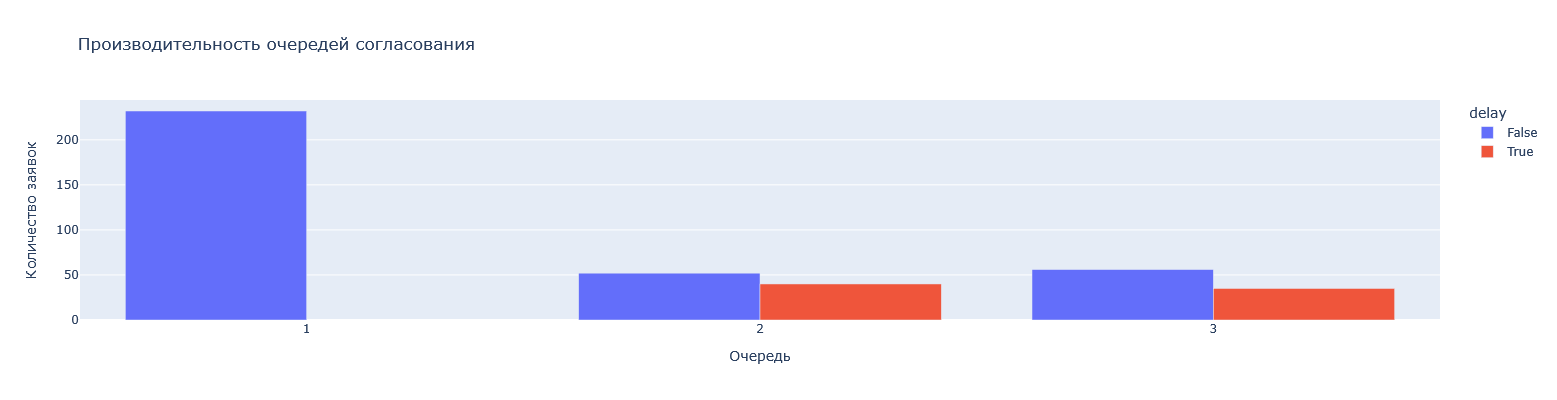

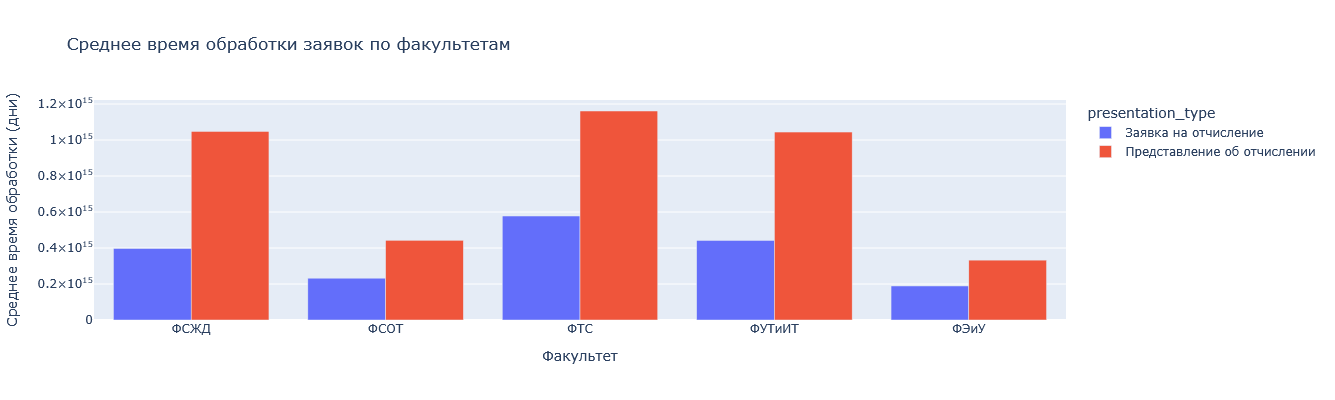

In [4]:
import pandas as pd
import plotly.express as px
from datetime import timedelta

# Предположим, что данные уже загружены в DataFrame df
# Если нет, используйте код из предыдущего сообщения для подключения к базе данных

# Преобразование дат в datetime
df['date_create'] = pd.to_datetime(df['date_create'], format='%d.%m.%Y')
df['approve_date'] = pd.to_datetime(df['approve_date'])
df['start_date'] = pd.to_datetime(df['start_date'])

# Добавляем столбец с временем обработки для каждой очереди
df['time_to_approve'] = df['approve_date'] - df['date_create']

# Функция для определения задержек
def check_delay(row):
    if row['queue'] == 2:
        return row['time_to_approve'] > timedelta(days=1)
    elif row['queue'] == 3:
        return row['time_to_approve'] > timedelta(days=2)
    return False

df['delay'] = df.apply(check_delay, axis=1)

# 1. Динамика создания заявок
df['year_month'] = df['date_create'].dt.to_period('M').astype(str)  # Группировка по месяцам
requests_by_type_and_time = df.groupby(['year_month', 'presentation_type']).size().reset_index(name='count')

fig_dynamics = px.line(
    requests_by_type_and_time,
    x='year_month',
    y='count',
    color='presentation_type',
    title='Динамика создания заявок по типам документов',
    markers=True,
    height=400,
    width=800
)
fig_dynamics.update_layout(xaxis_title='Месяц', yaxis_title='Количество заявок')

# 2. Статусы заявок
status_distribution = df.groupby(['presentation_type', 'sig_status_name']).size().reset_index(name='count')

fig_status = px.bar(
    status_distribution,
    x='sig_status_name',
    y='count',
    color='presentation_type',
    title='Распределение заявок по статусам',
    barmode='group',
    height=400,
    width=800
)
fig_status.update_layout(xaxis_title='Статус', yaxis_title='Количество заявок')

# 3. Производительность очередей согласования
queue_performance = df.groupby(['queue', 'delay']).size().reset_index(name='count')

fig_queue = px.bar(
    queue_performance,
    x='queue',
    y='count',
    color='delay',
    title='Производительность очередей согласования',
    barmode='group',
    height=400,
    width=800
)
fig_queue.update_layout(xaxis_title='Очередь', yaxis_title='Количество заявок')

# 4. Сравнение факультетов
faculty_performance = df.groupby(['fac_short_name', 'presentation_type'])['time_to_approve'].mean().reset_index()

fig_faculty = px.bar(
    faculty_performance,
    x='fac_short_name',
    y='time_to_approve',
    color='presentation_type',
    title='Среднее время обработки заявок по факультетам',
    barmode='group',
    height=400,
    width=800
)
fig_faculty.update_layout(xaxis_title='Факультет', yaxis_title='Среднее время обработки (дни)')

# Отображаем графики
fig_dynamics.show()
fig_status.show()
fig_queue.show()
fig_faculty.show()

In [5]:
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

# Предположим, что данные уже загружены в DataFrame df
# Если нет, используйте код из предыдущего сообщения для подключения к базе данных

# Преобразование дат в datetime
df['date_create'] = pd.to_datetime(df['date_create'], format='%d.%m.%Y')
df['approve_date'] = pd.to_datetime(df['approve_date'])
df['start_date'] = pd.to_datetime(df['start_date'])

# Функция для определения задержек
def check_delay(row):
    if row['queue'] == 2:
        return row['time_to_approve'] > pd.Timedelta(days=1)
    elif row['queue'] == 3:
        return row['time_to_approve'] > pd.Timedelta(days=2)
    return False

df['delay'] = df.apply(check_delay, axis=1)

# Группировка данных для графиков
requests_by_type_and_time = df.groupby(['date_create', 'presentation_type']).size().reset_index(name='count')

# Создаем Dash-приложение
app = dash.Dash(__name__)

# Макет дашборда
app.layout = html.Div([
    html.H1("Анализ процесса электронного согласования", style={'textAlign': 'center'}),
    
    # График динамики создания заявок
    dcc.Graph(id='dynamics-graph'),
    
    # Кнопка для сворачивания/разворачивания таблицы
    html.Button(
        "Показать/Скрыть таблицу",
        id="toggle-table-button",
        n_clicks=0,
        style={'marginTop': 20, 'marginBottom': 20}
    ),
    
    # Таблица для отображения данных (изначально скрыта)
    html.Div(
        id="table-container",
        children=[
            html.Table(id='details-table', style={'borderCollapse': 'collapse', 'width': '100%'})
        ],
        style={'display': 'none'}  # Начальное состояние: таблица скрыта
    )
])

# Обновление графика динамики создания заявок
@app.callback(
    Output('dynamics-graph', 'figure'),
    [Input('dynamics-graph', 'clickData')]
)
def update_dynamics_graph(click_data):
    fig = px.line(
        requests_by_type_and_time,
        x='date_create',
        y='count',
        color='presentation_type',
        title='Динамика создания заявок по типам документов',
        markers=True,
        height=400,
        width=800
    )
    fig.update_layout(
        xaxis_title='Месяц',
        yaxis_title='Количество заявок',
        legend_title='Тип документа'
    )
    return fig

# Обновление таблицы при клике на графике
@app.callback(
    Output('details-table', 'children'),
    [Input('dynamics-graph', 'clickData')]
)
def update_table(click_data):
    if click_data is None:
        return "Выберите точку на графике"
    
    # Получаем выбранный месяц из клика
    selected_date = click_data['points'][0]['x']
    
    # Фильтруем данные для выбранного месяца
    filtered_data = df[df['date_create'] == pd.to_datetime(selected_date)].copy()
    
    # Форматируем данные для пользователя
    filtered_data['Дата создания'] = filtered_data['date_create'].dt.strftime('%d.%m.%Y')
    filtered_data['Дата согласования'] = filtered_data['approve_date'].dt.strftime('%d.%m.%Y %H:%M')
    filtered_data['Дата предполагаемого отчисления'] = filtered_data['start_date'].dt.strftime('%d.%m.%Y')
    filtered_data['ФИО студента'] = filtered_data['fio']
    filtered_data['Факультет'] = filtered_data['fac_short_name']
    filtered_data['Тип документа'] = filtered_data['presentation_type']
    filtered_data['Статус согласования'] = filtered_data['sig_status_name']
    filtered_data['Очередь согласования'] = filtered_data['queue']
    filtered_data['Задержка'] = filtered_data['delay'].apply(lambda x: 'Да' if x else 'Нет')
    filtered_data['Время согласования'] = filtered_data['time_to_approve'].apply(
        lambda x: f"{x.days} дней {x.seconds // 3600} часов {(x.seconds // 60) % 60} минут" if pd.notnull(x) else "Не согласовано"
    )
    
    # Выбираем только нужные столбцы
    user_friendly_columns = [
        'Дата создания',
        'ФИО студента',
        'Факультет',
        'Тип документа',
        'Статус согласования',
        'Очередь согласования',
        'Дата согласования',
        'Дата предполагаемого отчисления',
        'Задержка',
        'Время согласования'
    ]
    filtered_data = filtered_data[user_friendly_columns]
    
    # Создаем HTML-таблицу с стилизацией ячеек
    table = [
        html.Tr(
            [html.Th(col, style={'border': '1px solid black', 'padding': '8px', 'backgroundColor': '#f2f2f2'}) for col in filtered_data.columns],
            style={'backgroundColor': '#f2f2f2'}
        )
    ] + [
        html.Tr(
            [html.Td(row[col], style={'border': '1px solid black', 'padding': '8px'}) for col in filtered_data.columns]
        ) for index, row in filtered_data.iterrows()
    ]
    return table

# Сворачивание/разворачивание таблицы
@app.callback(
    Output('table-container', 'style'),
    [Input('toggle-table-button', 'n_clicks')],
    [dash.dependencies.State('table-container', 'style')]
)
def toggle_table(n_clicks, current_style):
    if n_clicks % 2 == 0:
        return {'display': 'none'}  # Скрыть таблицу
    else:
        return {'display': 'block'}  # Показать таблицу

# Запуск приложения
if __name__ == '__main__':
    app.run(debug=True)

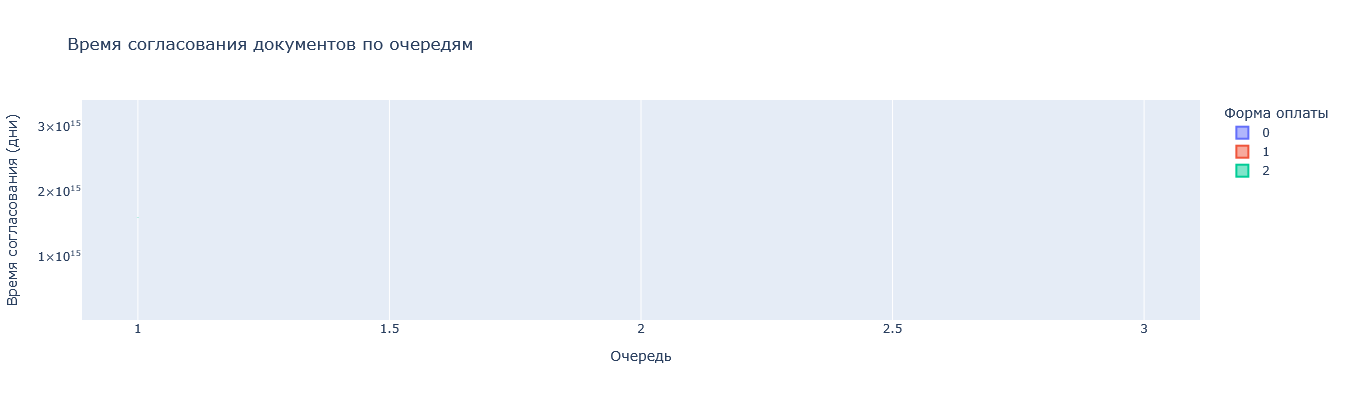

In [6]:
import pandas as pd
import plotly.express as px

# Фильтруем данные только для согласованных документов
filtered_data = df[df['time_to_approve'].notnull()]

# График времени согласования по очередям
fig = px.box(
    filtered_data,
    x='queue',
    y='time_to_approve',
    color='contract_id',  # Разделение по форме оплаты
    title='Время согласования документов по очередям',
    labels={'queue': 'Очередь', 'time_to_approve': 'Время согласования (дни)', 'contract_id': 'Форма оплаты'},
    height=400,
    width=800
)
fig.update_layout(legend_title='Форма оплаты')
fig.show()

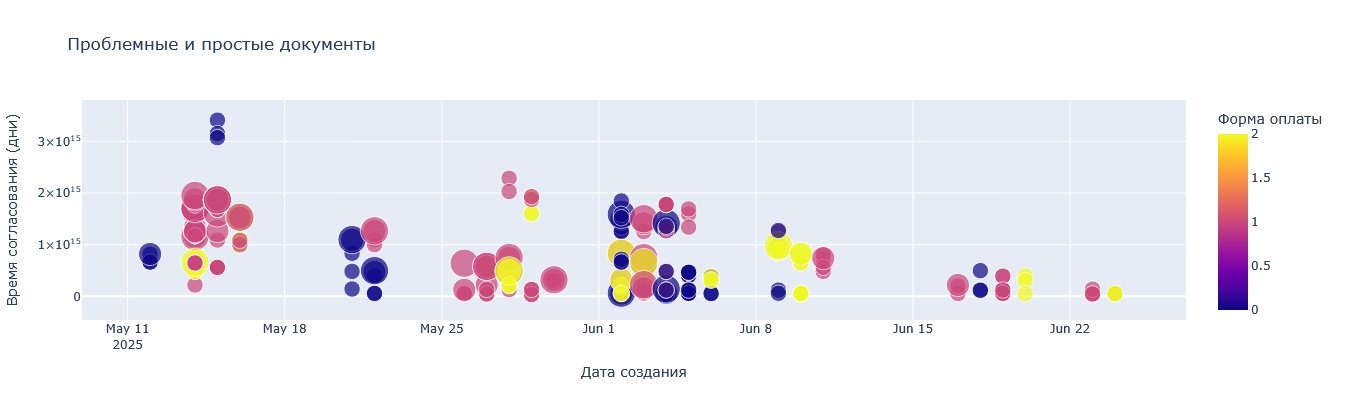

In [7]:
# Scatter plot для анализа проблемных и простых документов
fig = px.scatter(
    df,
    x='date_create',
    y='time_to_approve',
    color='contract_id',  # Разделение по форме оплаты
    size='queue',         # Размер точки зависит от очереди
    hover_data=['presentation_type', 'sig_status_name'],  # Детали при наведении
    title='Проблемные и простые документы',
    labels={'date_create': 'Дата создания', 'time_to_approve': 'Время согласования (дни)', 'contract_id': 'Форма оплаты'},
    height=400,
    width=800
)
fig.update_layout(legend_title='Форма оплаты')
fig.show()

In [8]:
# Группируем данные по согласователям и датам
reactivity_data = df.groupby(['name1', 'date_create'])['time_to_approve'].mean().reset_index()

# Линейный график времени реакции
fig = px.line(
    reactivity_data,
    x='date_create',
    y='time_to_approve',
    color='name1',  # Разделение по согласователям
    title='Время реакции согласователей',
    labels={'date_create': 'Дата', 'time_to_approve': 'Среднее время реакции (дни)', 'name1': 'Согласователь'},
    height=400,
    width=800
)
fig.update_layout(legend_title='Согласователь')
fig.show()

In [9]:
# Группируем данные по форме оплаты
payment_comparison = df.groupby(['contract_id', 'presentation_type'])['time_to_approve'].mean().reset_index()

# Столбчатая диаграмма
fig = px.bar(
    payment_comparison,
    x='contract_id',
    y='time_to_approve',
    color='presentation_type',  # Разделение по типу документа
    title='Сравнение времени согласования по формам оплаты',
    labels={'contract_id': 'Форма оплаты', 'time_to_approve': 'Среднее время согласования (дни)', 'presentation_type': 'Тип документа'},
    barmode='group',
    height=400,
    width=800
)
fig.update_layout(legend_title='Тип документа')
fig.show()

In [10]:
# Группируем данные по очередям и задержкам
bottleneck_data = df.groupby(['queue', 'delay']).size().reset_index(name='count')

# Тепловая карта
fig = px.density_heatmap(
    bottleneck_data,
    x='queue',
    y='delay',
    z='count',
    title='Узкие места в процессе согласования',
    labels={'queue': 'Очередь', 'delay': 'Задержка', 'count': 'Количество'},
    height=400,
    width=800
)
fig.update_layout(legend_title='Количество задержек')
fig.show()